# Airbnb Data Storytelling Case Study


| #   | Question                                                    | Intent                               |
| --- | ----------------------------------------------------------- | ------------------------------------ |
| 1 | Which cities are most expensive for Airbnb stays?           | Understand pricing trends            |
| 2 | What types of rooms are most preferred?                     | Identify customer preference         |
| 3 | How does availability vary across cities?                   | Measure demand-supply balance        |
| 4 | Is there any relationship between ratings and price?        | See if expensive = better            |
| 5 | Which hosts or listings are most engaging (reviews/month)?  | Find “Superhosts”                    |
| 6 | Which listings give best value — low cost but high ratings? | Identify “budget gems”               |

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("airbnb_listings_extended.csv")
df.sample(10)

,listing_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,city,rating
119,1120,John,Karol Bagh,Private room,5069,2,127,2.3,173,Delhi,4.6
18,1019,Sanya,MG Road,Private room,2094,3,79,2.7,185,Bangalore,4.7
56,1057,Aman,HSR Layout,Private room,4050,2,11,4.1,288,Bangalore,4.6
179,1180,Arjun,Madhapur,Entire home/apt,5967,3,170,1.2,154,Hyderabad,3.6
54,1055,David,Karol Bagh,Private room,5397,5,73,0.7,361,Delhi,4.9
60,1061,Rahul,Juhu,Private room,5640,4,108,0.6,279,Mumbai,4.0
99,1100,Aman,Banjara Hills,Entire home/apt,8552,2,121,4.5,289,Hyderabad,4.8
134,1135,Sanya,Anna Nagar,Private room,5795,1,69,2.4,201,Chennai,4.3
108,1109,Aman,Colaba,Entire home/apt,2681,2,16,4.3,296,Mumbai,4.8
167,1168,Divya,Indiranagar,Shared room,3093,2,30,2.7,175,Bangalore,4.9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   listing_id         200 non-null    int64  
 1   host_name          200 non-null    object 
 2   neighbourhood      200 non-null    object 
 3   room_type          200 non-null    object 
 4   price              200 non-null    int64  
 5   minimum_nights     200 non-null    int64  
 6   number_of_reviews  200 non-null    int64  
 7   reviews_per_month  200 non-null    float64
 8   availability_365   200 non-null    int64  
 9   city               200 non-null    object 
 10  rating             200 non-null    float64
dtypes: float64(2), int64(5), object(4)
memory usage: 17.3+ KB


<b>Q1: Which cities are most expensive for Airbnb stays?

In [9]:
df.groupby('city')['price'].mean().sort_values(ascending=False)

city
Delhi        5318.093750
Chennai      5085.096774
Pune         4857.393939
Mumbai       4619.533333
Bangalore    4440.515152
Hyderabad    4390.439024
Name: price, dtype: float64

<b>2: Which room types are most popular?


In [4]:
df['room_type'].value_counts()

Private room       79
Shared room        66
Entire home/apt    55
Name: room_type, dtype: int64

<b>3: Availability Patterns

In [12]:
df.groupby('city')['availability_365'].mean().sort_values(ascending=False)


city
Pune         235.606061
Mumbai       224.900000
Delhi        207.343750
Hyderabad    197.170732
Chennai      194.387097
Bangalore    181.545455
Name: availability_365, dtype: float64

<b>4: Price vs Rating — Does expensive mean better?

<AxesSubplot:xlabel='price', ylabel='rating'>

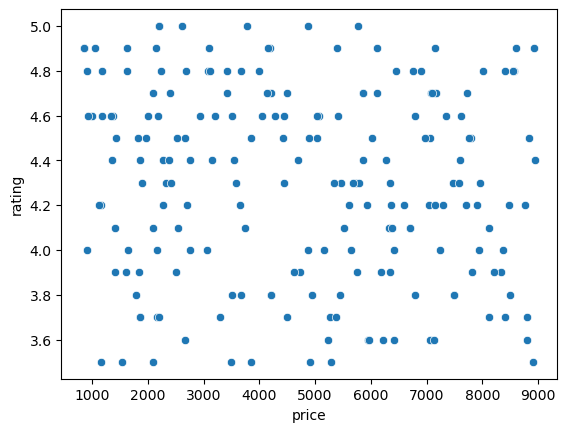

In [6]:
import seaborn as sns

sns.scatterplot(data=df, x='price', y='rating')

No strong relation

Some mid-range listings (2,000–3,000) have better ratings than expensive ones.

Expensive doesn’t always mean satisfying — comfort and experience often matter more than luxury

<b>5: Top Engaging Hosts

In [15]:
df.sort_values('reviews_per_month', ascending=False).head(10)

,listing_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,city,rating
82,1083,Sanya,HSR Layout,Entire home/apt,8842,4,132,5.0,184,Bangalore,4.5
189,1190,Alice,Saket,Private room,6347,5,133,4.9,323,Delhi,3.9
57,1058,Priya,Karol Bagh,Entire home/apt,4206,2,159,4.9,143,Delhi,3.8
149,1150,Divya,Bandra,Shared room,5676,2,65,4.9,352,Mumbai,4.3
162,1163,Priya,Juhu,Entire home/apt,7284,4,139,4.8,88,Mumbai,4.2
78,1079,Neha,Nungambakkam,Shared room,8932,4,199,4.8,164,Chennai,4.9
61,1062,Priya,Secunderabad,Private room,1964,1,147,4.8,301,Hyderabad,4.5
21,1022,Priya,Gachibowli,Entire home/apt,2401,2,118,4.8,123,Hyderabad,4.7
136,1137,David,Hinjewadi,Entire home/apt,3676,4,108,4.7,67,Pune,4.8
74,1075,David,Indiranagar,Entire home/apt,7340,3,22,4.7,197,Bangalore,4.6


It’s not about price or city — engagement depends on the human touch of the host.

<b>6: Budget-friendly High-rated Listings

In [7]:
df[(df['price'] < df['price'].mean()) & (df['rating'] >= 4.6)].head(10)

,listing_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,city,rating
3,1004,Sophia,Hinjewadi,Shared room,3417,5,184,1.5,188,Pune,4.7
4,1005,Kiran,Kalyani Nagar,Shared room,2151,2,79,3.9,345,Pune,4.9
7,1008,Sophia,Anna Nagar,Private room,911,3,111,2.1,304,Chennai,4.8
8,1009,Ravi,Secunderabad,Private room,4206,4,163,0.9,240,Hyderabad,4.7
18,1019,Sanya,MG Road,Private room,2094,3,79,2.7,185,Bangalore,4.7
21,1022,Priya,Gachibowli,Entire home/apt,2401,2,118,4.8,123,Hyderabad,4.7
34,1035,Ravi,Bandra,Shared room,1621,3,15,0.8,53,Mumbai,4.8
38,1039,Neha,Hinjewadi,Entire home/apt,4279,3,198,1.3,354,Pune,4.6
42,1043,Sophia,Jubilee Hills,Private room,4198,4,89,1.9,288,Hyderabad,4.9
48,1049,Aman,Secunderabad,Entire home/apt,1181,4,37,4.2,285,Hyderabad,4.6


Many in Hyderabad, Pune offer high value ,affordable yet well-rated.

These can be marketed as “Hidden Gems” or “Value Stay” segments.